Also, known as text generation step

In [2]:
%matplotlib inline

import torch
import matplotlib.pyplot as plt

import tiktoken

from utils import text_to_token_ids, token_ids_to_text

In [6]:
vocab={word:i for i, word in enumerate(["closer","every","effort","forward","inches","moves","pizza","toward","you"])}
print(f"{len(vocab)=}, {vocab=}")
inverse_vocab={v:k for k, v in vocab.items()}
print(f"{inverse_vocab=}")

start_context="every effort moves you"
next_token_logits=torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
probs=torch.softmax(next_token_logits, dim=0)
next_token_id=torch.argmax(probs).item()
print(f"{len(probs)=} {next_token_id=}, {inverse_vocab[next_token_id]}")

len(vocab)=9, vocab={'closer': 0, 'every': 1, 'effort': 2, 'forward': 3, 'inches': 4, 'moves': 5, 'pizza': 6, 'toward': 7, 'you': 8}
inverse_vocab={0: 'closer', 1: 'every', 2: 'effort', 3: 'forward', 4: 'inches', 5: 'moves', 6: 'pizza', 7: 'toward', 8: 'you'}
len(probs)=9 next_token_id=3, forward


### Temperature scaling

In [3]:
torch.manual_seed(123)
next_token_id=torch.multinomial(probs, num_samples=1).item()
print(f"{next_token_id=}, {inverse_vocab[next_token_id]}")

next_token_id=7, toward


In [8]:
torch.manual_seed(123)
sample=[torch.multinomial(probs, num_samples=1).item() for _ in range(1000)]
print(f"{sample[:100]=}")
sampled_ids=torch.bincount(torch.tensor(sample))
print(f"{sampled_ids.shape=}, {sampled_ids=}")
for i, freq in enumerate(sampled_ids): print(f"{i}: {freq} x {inverse_vocab[i]}")


sample[:100]=[7, 3, 7, 3, 3, 8, 3, 3, 3, 0, 3, 3, 0, 3, 7, 3, 3, 3, 7, 7, 7, 7, 7, 7, 3, 7, 7, 3, 7, 3, 3, 7, 7, 7, 7, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 7, 3, 3, 3, 3, 3, 3, 7, 3, 7, 7, 3, 7, 0, 3, 3, 3, 3, 3, 3, 3, 3, 7, 3, 7, 3, 7, 7, 3, 3, 3, 3, 0, 7, 7, 3, 3, 7, 7, 0, 0, 0, 3, 3, 7, 3, 3]
sampled_ids.shape=torch.Size([9]), sampled_ids=tensor([ 71,   2,   0, 544,   2,   1,   0, 376,   4])
0: 71 x closer
1: 2 x every
2: 0 x effort
3: 544 x forward
4: 2 x inches
5: 1 x moves
6: 0 x pizza
7: 376 x toward
8: 4 x you


In [15]:
def print_sampled_tokens(probs):
    torch.manual_seed(123)
    sample=[torch.multinomial(probs, num_samples=1).item() for _ in range(1000)]
    sampled_ids=torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids): print(f"{freq} x {inverse_vocab[i]}")

def softmax_with_temperature(logits, temperature):
    """
    Computed a scaled distribution of logits
    Args:
        logits (torch.Tensor): Input logits of shape (..., embed_dim)
        temperature (float): Smaller than 1 resulting in sharper distribution (making the logit with the highest value having probability
            mass close to 1); Higher than 1 making the distribution more uniform (each logit has much more equal probability mass)
    Returns:
        (torch.Tensor): Probability distribution of shape (..., embed_dim)
    """
    scaled_logits=logits/temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures=[1.,0.1,5.] # original, higher, and lower confidence
scaled_probs=[softmax_with_temperature(next_token_logits, t) for t in temperatures]
print(f"{[s.shape for s in scaled_probs]=}\n{scaled_probs=}")

print("Original distribution")
print_sampled_tokens(torch.softmax(next_token_logits, dim=0))
print("Scaled duistribution")
print_sampled_tokens(softmax_with_temperature(next_token_logits, 5.))

[s.shape for s in scaled_probs]=[torch.Size([9]), torch.Size([9]), torch.Size([9])]
scaled_probs=[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03]), tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22]), tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]
Original distribution
71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you
Scaled duistribution
153 x closer
68 x every
55 x effort
223 x forward
102 x inches
50 x moves
43 x pizza
218 x toward
88 x you


In [19]:
sample=torch.multinomial(softmax_with_temperature(next_token_logits, 5.), num_samples=1000, replacement=True)
sampled_ids=torch.bincount(sample)
print(f"{sampled_ids=}")
for i, freq in enumerate(sampled_ids): print(f"{freq} x {inverse_vocab[i]}")

sampled_ids=tensor([131,  83,  46, 230,  94,  34,  50, 235,  97])
131 x closer
83 x every
46 x effort
230 x forward
94 x inches
34 x moves
50 x pizza
235 x toward
97 x you


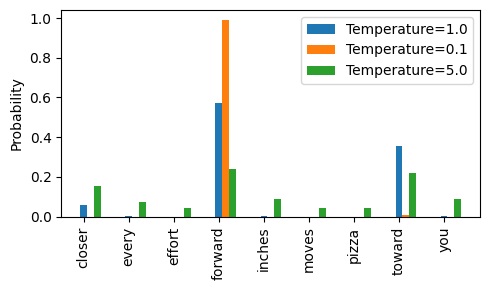

In [13]:
x=torch.arange(len(vocab))
bar_width=0.15
fig, ax=plt.subplots(figsize=(5,3))
for i, t in enumerate(temperatures):
    rects=ax.bar(x+i*bar_width, scaled_probs[i], bar_width, label=f"Temperature={t}")
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()

### Top-k sampling

In [22]:
top_k=3
top_logits, top_pos=torch.topk(next_token_logits, top_k) # return values ordered from highest to lowest in the top-k selection
print(f"{top_logits=}, {top_pos=}")
new_logits=torch.where(condition=next_token_logits<top_logits[-1],  # select logits less than the minimum in the top k
                       input=torch.tensor(float('-inf')), # assign -inf to low logits
                       other=next_token_logits # retain the original logits of the selected top-k
                      )
print(f"{new_logits=}")
topk_probs=torch.softmax(new_logits, dim=0)
print(f"{topk_probs=}")

top_logits=tensor([6.7500, 6.2800, 4.5100]), top_pos=tensor([3, 7, 0])
new_logits=tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
topk_probs=tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [23]:
def generate(model, idx, max_new_tokens, context_size, temperature=0., top_k=None, eos_id=None):
    """
    Incorporate temperature scaling and top-k and multinomial sampling to generate text
    Args:
        idx (torch.Tensor): Input token indices of size (batch_size, seq_len/num_tokens)
        max_new_tokens (int): The maximum number of new tokens to be generated
        eos_id (torch.Tensor): Index of end-of-sequence token. If provided and detected, stop generating text 
    
    """
    for _ in range(max_new_tokens):
        print('-'*50)
        idx_cond=idx[:, -context_size:] # truncate the token indices to the context-length
        with torch.no_grad(): logits=model(idx_cond)
        print(f"{logits.shape=}")
        logits=logits[:,-1] # only focus on the logit of the last token
        print(f"{logits.shape=}")
        if top_k is not None: # filter logits with top-k sampling
            top_logits,_=torch.topk(logits, top_k)
            min_val=top_logits[:,-1]
            logits=torch.where(logits<min_val, torch.tensor(float('-inf')).to(logits.device), logits)
        if temperature>0.: # applying temperature scaling
            logits=logits/temperature
            probs=torch.softmax(logits, dim=-1)
            idx_next=torch.multinomial(probs, num_samples=1)
        else: idx_next=torch.argmax(logits, dim=-1, keepdim=True) # greedy next token selection

        if idx_next==eos_id: break
        print(f"{idx.shape=}, {idx_next.shape=}")
        idx=torch.cat((idx, idx_next), dim=-1)

    return idx

torch.manual_seed(123)
tokenizer=tiktoken.get_encoding('gpt2')
token_ids=generate(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer=tokenizer), 
                   max_new_tokens=15, context_size=256, top_k=25, temperature=1.4) # more uniform than sharp
print(f"")

In [13]:
batch_size=5
x=torch.rand(batch_size,10)
x.shape, x

(torch.Size([5, 10]),
 tensor([[0.9435, 0.7499, 0.8083, 0.1652, 0.6000, 0.2170, 0.0439, 0.1857, 0.1783,
          0.0884],
         [0.4180, 0.3283, 0.3537, 0.4423, 0.1488, 0.0053, 0.9050, 0.9734, 0.0521,
          0.3849],
         [0.9766, 0.4553, 0.4477, 0.2617, 0.9931, 0.2405, 0.9878, 0.0275, 0.2650,
          0.1857],
         [0.9940, 0.3551, 0.3704, 0.1559, 0.4529, 0.2712, 0.9018, 0.0422, 0.0610,
          0.4864],
         [0.4211, 0.4551, 0.4029, 0.2772, 0.4476, 0.1140, 0.5883, 0.0176, 0.5750,
          0.6648]]))

In [21]:
torch.multinomial(x, num_samples=1).shape

torch.Size([5, 1])

In [14]:
y=torch.rand(batch_size)
y.shape, y

(torch.Size([5]), tensor([0.6460, 0.8613, 0.0488, 0.4816, 0.8338]))

In [17]:
torch.where(x<y[:,None], torch.tensor(float('-inf')), x).shape

torch.Size([5, 10])

In [ ]:
logits=torch.where(logits<min_val, torch.tensor(float('-inf')).to(logits.device), logits)

In [ ]:
logits.shape=torch.Size([1, 4, 50257])
logits.shape=torch.Size([1, 50257])
top_logits.shape=torch.Size([1, 25]), min_val.shape=torch.Size([1]), logits.shape=torch.Size([1, 50257])
probs.shape=torch.Size([1, 50257]), idx_next.shape=torch.Size([1, 1])
idx.shape=torch.Size([1, 4]), idx_next.shape=torch.Size([1, 1])